<a href="https://www.kaggle.com/code/khoaduongcodenew/notebook?scriptVersionId=353657169" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Notebook 01: Dataset EDA & Split Preparation


## 1. Kaggle Environment

*Thiết lập môi trường trên Kaggle (GPU, cloned repo, output directories).*


In [11]:
# Xử lý dữ liệu và tính toán số học
import numpy as np
import pandas as pd

# Trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Thuật toán mẫu (Ví dụ: Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Cấu hình hiển thị
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 2. Dataset Discovery

*Quét và định vị thư mục dataset WLASL-2000 Resized trong /kaggle/input.*


In [12]:
# 1. Đọc dữ liệu (thay đường dẫn file .csv của bạn hoặc dùng dataset mẫu)

# Ví dụ dùng Iris dataset có sẵn trong sklearn:
from sklearn.datasets import load_iris
raw_data = load_iris(as_frame=True)
df = raw_data.frame

# 2. Xem 5 dòng đầu tiên
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
# 3. Kiểm tra kiểu dữ liệu, số lượng dòng/cột và giá trị khuyết thiếu (missing values)
print("--- THÔNG TIN DATASET ---")
df.info()

print("\n--- THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATS) ---")
df.describe().T

--- THÔNG TIN DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

--- THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATS) ---


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


## 3. Read WLASL Metadata

*Đọc và phân tích file metadata (WLASL_v0.3.json).*


In [14]:
import json, pandas as pd

data = json.load(open("/kaggle/input/datasets/sttaseen/wlasl2000-resized/wlasl-complete/WLASL_v0.3.json"))
rows = []
for g in data:
    for inst in g["instances"]:
        rows.append({
            "gloss": g["gloss"],
            "video_id": inst["video_id"],
            "split": inst["split"],
            "signer_id": inst["signer_id"],
            "fps": inst["fps"],
            "frame_start": inst["frame_start"],
            "frame_end": inst["frame_end"],
            "source": inst["source"],
        })
df = pd.DataFrame(rows)

per_class = df.groupby("gloss").size()
print(per_class.describe())            # samples/class
print(df["split"].value_counts())      # train/val/test
print(df["signer_id"].nunique())       # số signer
print(df["fps"].value_counts())        # FPS

# signer overlap giữa train và test
tr = set(df[df.split=="train"].signer_id)
te = set(df[df.split=="test"].signer_id)
print("signer trùng train/test:", len(tr & te))

count    2000.000000
mean       10.541500
std         3.547192
min         6.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        40.000000
dtype: float64
split
train    14289
val       3916
test      2878
Name: count, dtype: int64
119
fps
25    21083
Name: count, dtype: int64
signer trùng train/test: 104


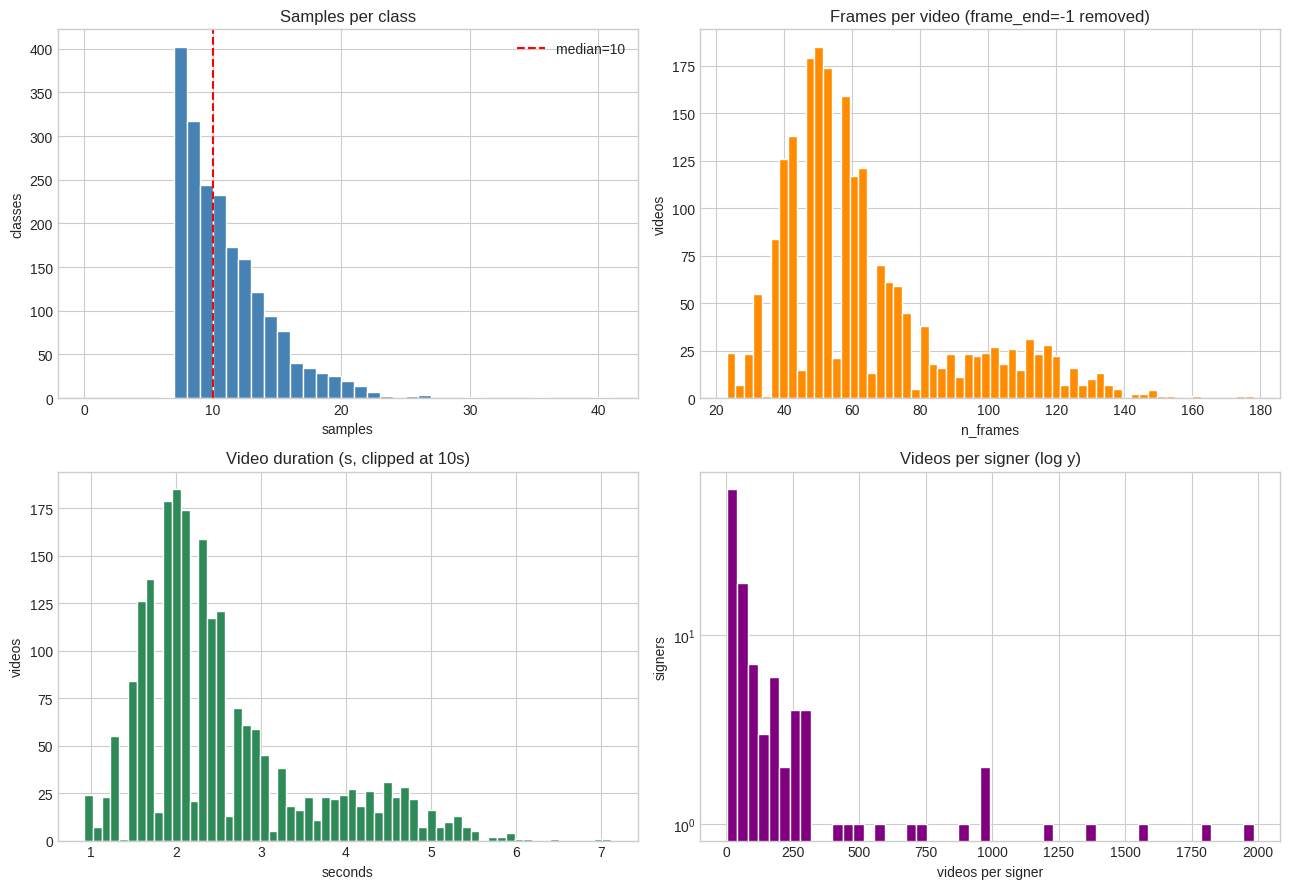

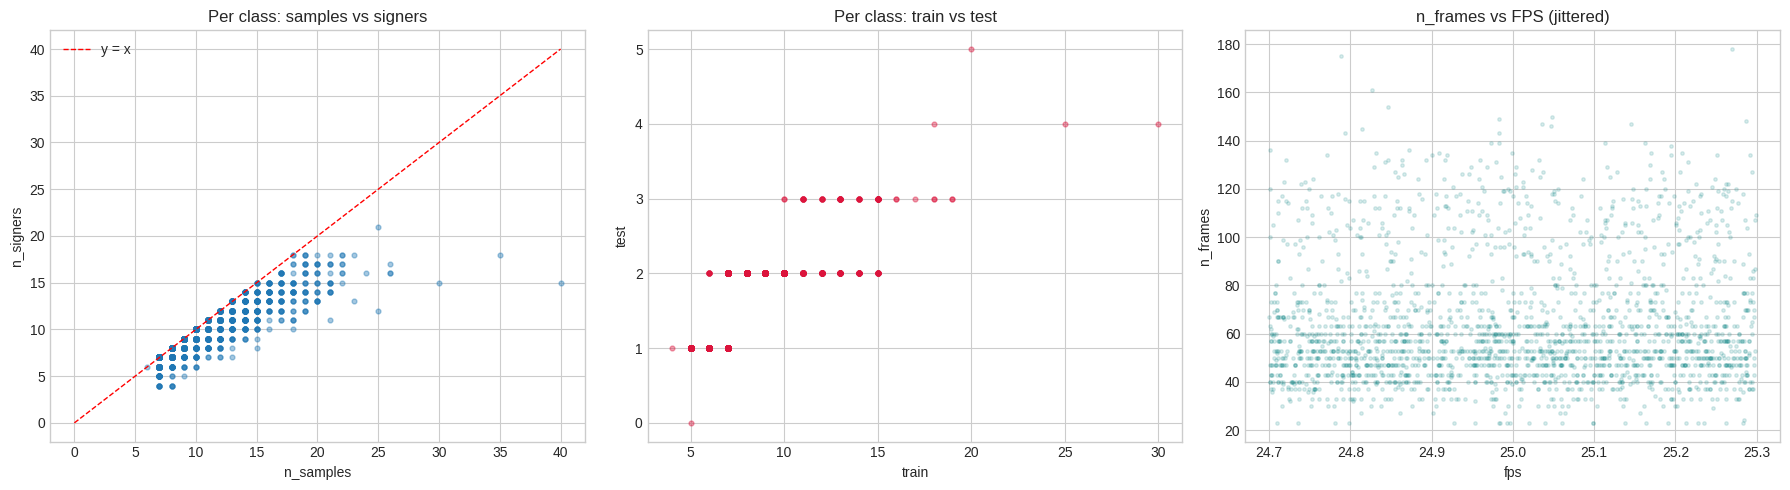

Class ít mẫu nhất:
 gloss
caterpillar    6
accent         7
act            7
adapt          7
adjective      7
dtype: int64
Class không có mẫu test: 1
Class chỉ có 1 signer: 0


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Feature phụ ---
# frame_end = -1 nghĩa là lấy đến hết video
d = df[df["frame_end"] > 0].copy()
d["n_frames"] = d["frame_end"] - d["frame_start"] + 1
d["duration_s"] = d["n_frames"] / d["fps"]

per_class_df = df.groupby("gloss").agg(
    n_samples=("video_id", "size"),
    n_signers=("signer_id", "nunique"),
)
split_ct = df.pivot_table(index="gloss", columns="split",
                          values="video_id", aggfunc="count", fill_value=0)

# --- Histogram ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(per_class, bins=range(0, per_class.max() + 2), color="steelblue", edgecolor="white")
axes[0, 0].set(title="Samples per class", xlabel="samples", ylabel="classes")
axes[0, 0].axvline(per_class.median(), color="red", ls="--", label=f"median={per_class.median():.0f}")
axes[0, 0].legend()

axes[0, 1].hist(d["n_frames"], bins=60, color="darkorange", edgecolor="white")
axes[0, 1].set(title="Frames per video (frame_end=-1 removed)", xlabel="n_frames", ylabel="videos")

axes[1, 0].hist(d["duration_s"].clip(upper=10), bins=60, color="seagreen", edgecolor="white")
axes[1, 0].set(title="Video duration (s, clipped at 10s)", xlabel="seconds", ylabel="videos")

sig_ct = df["signer_id"].value_counts()
axes[1, 1].hist(sig_ct, bins=50, color="purple", edgecolor="white")
axes[1, 1].set_yscale("log")
axes[1, 1].set(title="Videos per signer (log y)", xlabel="videos per signer", ylabel="signers")

plt.tight_layout()
plt.show()

# --- Scatter ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Samples vs signers per class
axes[0].scatter(per_class_df["n_samples"], per_class_df["n_signers"], alpha=0.4, s=12)
axes[0].plot([0, per_class_df["n_samples"].max()], [0, per_class_df["n_samples"].max()],
             "r--", lw=1, label="y = x")
axes[0].set(title="Per class: samples vs signers", xlabel="n_samples", ylabel="n_signers")
axes[0].legend()

# 2) Train vs test count per class
axes[1].scatter(split_ct["train"], split_ct["test"], alpha=0.4, s=12, color="crimson")
axes[1].set(title="Per class: train vs test", xlabel="train", ylabel="test")

# 3) Frames vs FPS
axes[2].scatter(d["fps"] + np.random.uniform(-0.3, 0.3, len(d)), d["n_frames"],
                alpha=0.15, s=6, color="teal")   # jitter because fps is discrete
axes[2].set(title="n_frames vs FPS (jittered)", xlabel="fps", ylabel="n_frames")
plt.tight_layout()
plt.show()

# --- Các con số đáng chú ý ---
print("Class ít mẫu nhất:\n", per_class.nsmallest(5))
print("Class không có mẫu test:", (split_ct["test"] == 0).sum())
print("Class chỉ có 1 signer:", (per_class_df["n_signers"] == 1).sum())

## 4. Dataset Statistics

*Thống kê tổng quan về số từ vựng (glosses), tổng số video, độ dài trung bình.*


## 5. Class Distribution

*Phân tích phân bố tần suất của các classes trong dataset.*


## 6. Video Statistics

*Kiểm tra tính sẵn sàng của video trên disk (tồn tại/thiếu, FPS, resolution).*


## 7. Signer Distribution

*Thống kê số lượng người ký (signer identity) và phân bố mẫu theo từng signer.*


## 8. Official Train/Val/Test Analysis

*Phân tích các tập split chính thức và kiểm tra mức độ trùng lặp signer (data leakage).*


## 9. Select Initial 5 Classes

*Chọn ra 5 classes khởi đầu có nhiều mẫu video nhất.*


## 10. Visual Inspection

*Trực quan hóa và kiểm tra frame mẫu từ các video của 5 classes đã chọn.*


## 11. Save Selected Split CSV

*Lưu các file split CSV (train.csv, val.csv, test.csv) cho 5 classes đã chọn và dừng lại.*
